# Linear regression showdown

## Import necessary libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression as SklearnLinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from src.models.linear_regression import LinearRegression as MlFunLinearRegression

import pathlib

## Load data into Dataframe

In [2]:
BASE_DIR = pathlib.Path(".").resolve()
REGRESSION_PATH = BASE_DIR / "data" / "Car_Price_Prediction.csv"

In [3]:
df = pd.read_csv(REGRESSION_PATH)
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


## Drop non-numeric tables

In [4]:
df = df.select_dtypes(include="number")

## Explore the dataset

### Visualise data

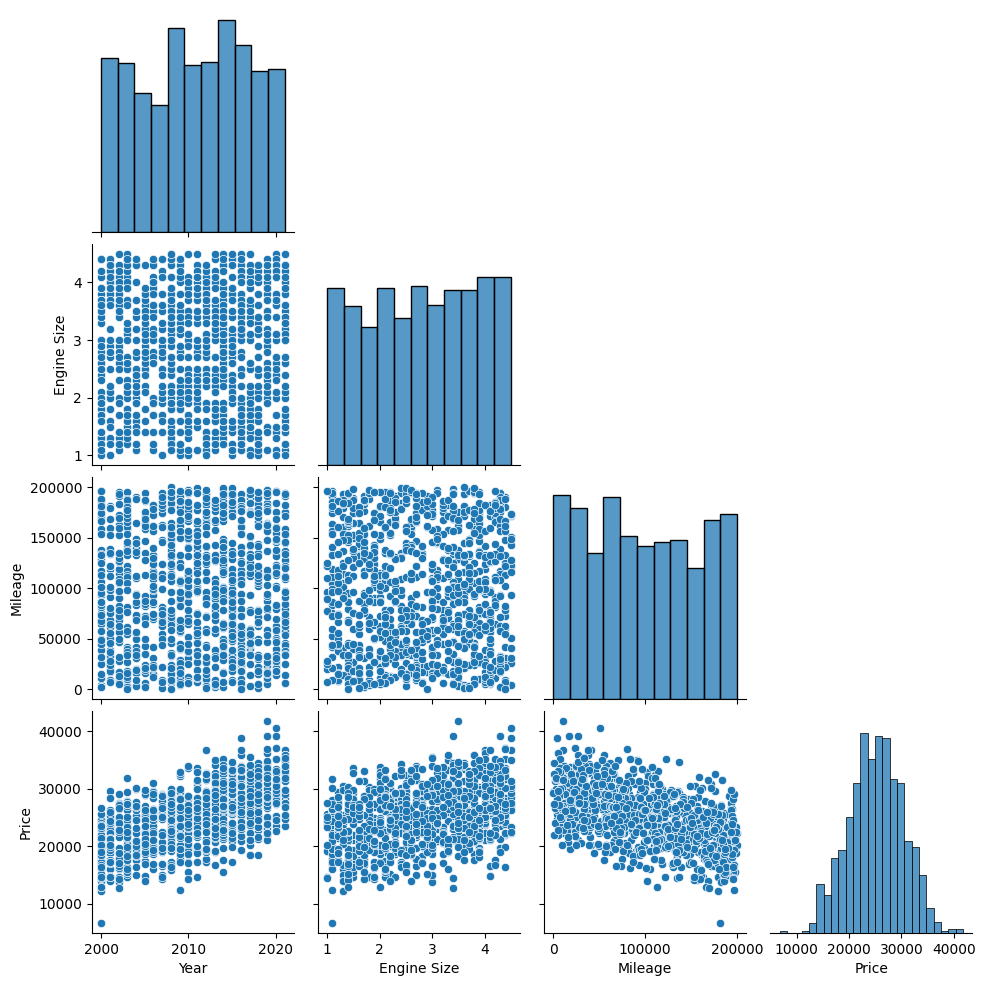

In [5]:
sns.pairplot(data=df, corner=True)

### Correlation heatmap

<Axes: >

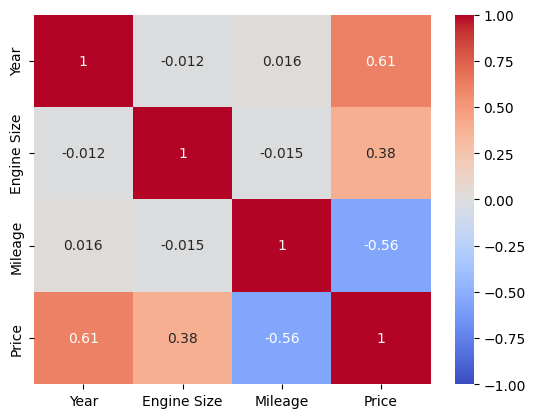

In [6]:
corr = df.corr(numeric_only=True)

sns.heatmap(data=corr, vmin=-1, vmax=1, cmap="coolwarm", annot=True)

## Train models

### Split the dataset into test and train

In [7]:
y = df[["Price"]]
X = df.drop(columns=y.columns)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

### Adjust data to models

In [9]:
# MLFun supports only operations on numpy matrices
# and normalizes features by default
X_train_mlfun = X_train.to_numpy()
y_train_mlfun = y_train["Price"].to_numpy()

X_test_mlfun = X_test.to_numpy()
y_test_mlfun = y_test["Price"].to_numpy()

In [10]:
# Sklearn needs scaler (in this case we use StandardScaler)
# to normalize features before training and testing model
scaler = StandardScaler()

X_train_sklearn = scaler.fit_transform(X_train)
X_test_sklearn = scaler.transform(X_test)

y_train_sklearn = y_train["Price"]
y_test_sklearn = y_test["Price"]

### Train the models

In [11]:
%%time
scikit_model = SklearnLinearRegression().fit(X_train_sklearn, y_train_sklearn)

CPU times: total: 0 ns
Wall time: 1.6 ms


In [12]:
%%time
mlfun_model = MlFunLinearRegression().fit(X_train_mlfun, y_train_mlfun)

CPU times: total: 93.8 ms
Wall time: 82.9 ms


### Evaluate performance

In [13]:
scikit_pred = scikit_model.predict(X_test_sklearn)
root_mean_squared_error(y_test_sklearn, scikit_pred)

2139.5559897489584

In [14]:
mlfun_pred = mlfun_model.predict(X_test_mlfun)
root_mean_squared_error(y_test_mlfun, mlfun_pred)

2139.556116259722

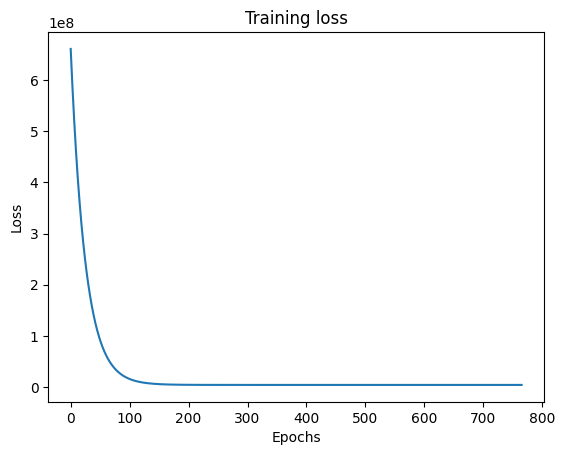

In [15]:
mlfun_model.plot_losses()